## Creating Model

We will now create the model using SMOTE to handle the imbalanced dataset as well as XGboost to minimize errors.

In [7]:
import kagglehub
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import xgboost as xgb
from sklearn.model_selection import cross_val_score, StratifiedKFold, train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, average_precision_score, confusion_matrix
)
from imblearn.over_sampling import SMOTE

# LOAD DATA
path = kagglehub.dataset_download("mlg-ulb/creditcardfraud")
csv_file_path = os.path.join(path, "creditcard.csv")
df = pd.read_csv(csv_file_path)

X = df.drop(['Class'], axis=1)
y = df['Class']

# SPLIT DATA
X_temp, X_test, y_temp, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

X_train, X_val, y_train, y_val = train_test_split(
    X_temp, y_temp, test_size=0.25, random_state=42, stratify=y_temp
)

print(f"Training:   {len(X_train):,} samples ({y_train.sum()} frauds)")
print(f"Validation: {len(X_val):,} samples ({y_val.sum()} frauds)")
print(f"Test:       {len(X_test):,} samples ({y_test.sum()} frauds)")

# Scale
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)
X_test_scaled = scaler.transform(X_test)

# APPLY SMOTE
smote = SMOTE(random_state=42, k_neighbors=5)
X_train_smote, y_train_smote = smote.fit_resample(X_train_scaled, y_train)

print(f"Before SMOTE: {(y_train==0).sum():,} normal, {(y_train==1).sum()} fraud")
print(f"After SMOTE:  {(y_train_smote==0).sum():,} normal, {(y_train_smote==1).sum():,} fraud")

scale_weights = [3.0, 4.0, 5.0, 6.0, 7.0, 8.0]
max_depths = [6, 7, 8]
learning_rates = [0.08, 0.1, 0.12]

total_configs = len(scale_weights) * len(max_depths) * len(learning_rates)
print(f"Testing {total_configs} recall-optimized configurations...")

best_recall_score = 0
best_params = None
best_model = None
results_comparison = []

config_num = 0
for scale_weight in scale_weights:
    for max_depth in max_depths:
        for lr in learning_rates:
            config_num += 1
            
            xgb_params = {
                'max_depth': max_depth,
                'learning_rate': lr,
                'n_estimators': 250,  # More trees
                'objective': 'binary:logistic',
                'scale_pos_weight': scale_weight,  # HIGH for recall
                'subsample': 0.85,
                'colsample_bytree': 0.85,
                'reg_alpha': 0.02,  # LOW regularization
                'reg_lambda': 0.6,
                'min_child_weight': 1,  # LOW = more splits
                'random_state': 42,
                'eval_metric': 'aucpr'
            }
            
            model = xgb.XGBClassifier(**xgb_params)
            model.fit(X_train_smote, y_train_smote, verbose=False)
            
            y_val_pred = model.predict(X_val_scaled)
            y_val_proba = model.predict_proba(X_val_scaled)[:, 1]
            
            val_precision = precision_score(y_val, y_val_pred, zero_division=0)
            val_recall = recall_score(y_val, y_val_pred, zero_division=0)
            val_f1 = f1_score(y_val, y_val_pred, zero_division=0)
            val_pr_auc = average_precision_score(y_val, y_val_proba)
            
            results_comparison.append({
                'scale_pos_weight': scale_weight,
                'max_depth': max_depth,
                'learning_rate': lr,
                'precision': val_precision,
                'recall': val_recall,
                'f1': val_f1,
                'pr_auc': val_pr_auc
            })
            
            # prioritize recall
            if val_precision >= 0.70 and val_recall > best_recall_score:
                best_recall_score = val_recall
                best_params = xgb_params.copy()
                best_model = model
            
            if config_num % 9 == 0 or config_num == total_configs:
                print(f"  {config_num}/{total_configs} | Best recall: {best_recall_score*100:.2f}%")

print(f"\n BEST RECALL-FOCUSED CONFIG:")
print(f"  scale_pos_weight: {best_params['scale_pos_weight']}")
print(f"  max_depth: {best_params['max_depth']}")
print(f"  learning_rate: {best_params['learning_rate']}")
print(f"  Validation recall: {best_recall_score*100:.2f}%")


# TRAIN FINAL MODEL

X_train_full = np.vstack([X_train_scaled, X_val_scaled])
y_train_full = np.concatenate([y_train, y_val])

smote_full = SMOTE(random_state=42, k_neighbors=5)
X_train_full_smote, y_train_full_smote = smote_full.fit_resample(X_train_full, y_train_full)

final_model = xgb.XGBClassifier(**best_params)
final_model.fit(X_train_full_smote, y_train_full_smote, verbose=False)


# EVALUATE ON TEST SET

y_pred_test = final_model.predict(X_test_scaled)
y_proba_test = final_model.predict_proba(X_test_scaled)[:, 1]

test_metrics = {
    'accuracy': accuracy_score(y_test, y_pred_test),
    'precision': precision_score(y_test, y_pred_test, zero_division=0),
    'recall': recall_score(y_test, y_pred_test, zero_division=0),
    'f1': f1_score(y_test, y_pred_test, zero_division=0),
    'roc_auc': roc_auc_score(y_test, y_proba_test),
    'pr_auc': average_precision_score(y_test, y_proba_test)
}

print("\n" + "="*70)
print("RECALL-FOCUSED RESULTS")
print("="*70)
print(f"  Precision: {test_metrics['precision']*100:.2f}%")
print(f"  Recall:    {test_metrics['recall']*100:.2f}%")
print(f"  F1-Score:  {test_metrics['f1']*100:.2f}%")
print(f"  PR-AUC:    {test_metrics['pr_auc']:.4f}")

# Confusion matrix
cm = confusion_matrix(y_test, y_pred_test)
tn, fp, fn, tp = cm.ravel()
total_frauds = tp + fn
total_normal = tn + fp

print(f"\nConfusion Matrix:")
print(cm)
print(f"\n  Frauds caught: {tp}/{total_frauds} ({tp/total_frauds*100:.1f}%)")
print(f"  Frauds missed: {fn}/{total_frauds} ({fn/total_frauds*100:.1f}%)")
print(f"  False alarms: {fp} ({fp/total_normal*100:.4f}% FP rate)")

# Feature importance
feature_importance = pd.DataFrame({
    'feature': X.columns,
    'importance': final_model.feature_importances_
}).sort_values('importance', ascending=False)

print("\nTop 10 Features:")
print(feature_importance.head(10).to_string(index=False))

Training:   170,883 samples (295 frauds)
Validation: 56,962 samples (99 frauds)
Test:       56,962 samples (98 frauds)
Before SMOTE: 170,588 normal, 295 fraud
After SMOTE:  170,588 normal, 170,588 fraud
Testing 54 recall-optimized configurations...
  9/54 | Best recall: 78.79%
  18/54 | Best recall: 78.79%
  27/54 | Best recall: 78.79%
  36/54 | Best recall: 78.79%
  45/54 | Best recall: 78.79%
  54/54 | Best recall: 78.79%

 BEST RECALL-FOCUSED CONFIG:
  scale_pos_weight: 3.0
  max_depth: 6
  learning_rate: 0.12
  Validation recall: 78.79%

RECALL-FOCUSED RESULTS
  Precision: 68.33%
  Recall:    83.67%
  F1-Score:  75.23%
  PR-AUC:    0.8587

Confusion Matrix:
[[56826    38]
 [   16    82]]

  Frauds caught: 82/98 (83.7%)
  Frauds missed: 16/98 (16.3%)
  False alarms: 38 (0.0668% FP rate)

Top 10 Features:
feature  importance
    V14    0.329911
    V10    0.249038
     V4    0.053961
     V8    0.042323
    V17    0.031385
    V12    0.025911
    V18    0.023039
    V20    0.019817
 


Sweeping thresholds from 0.01 to 0.99...
Tested 99 thresholds

F1-Optimal Threshold: 0.960
  Precision: 95.24%
  Recall: 81.63%
  F1-Score: 87.91%
  Frauds caught: 80/98


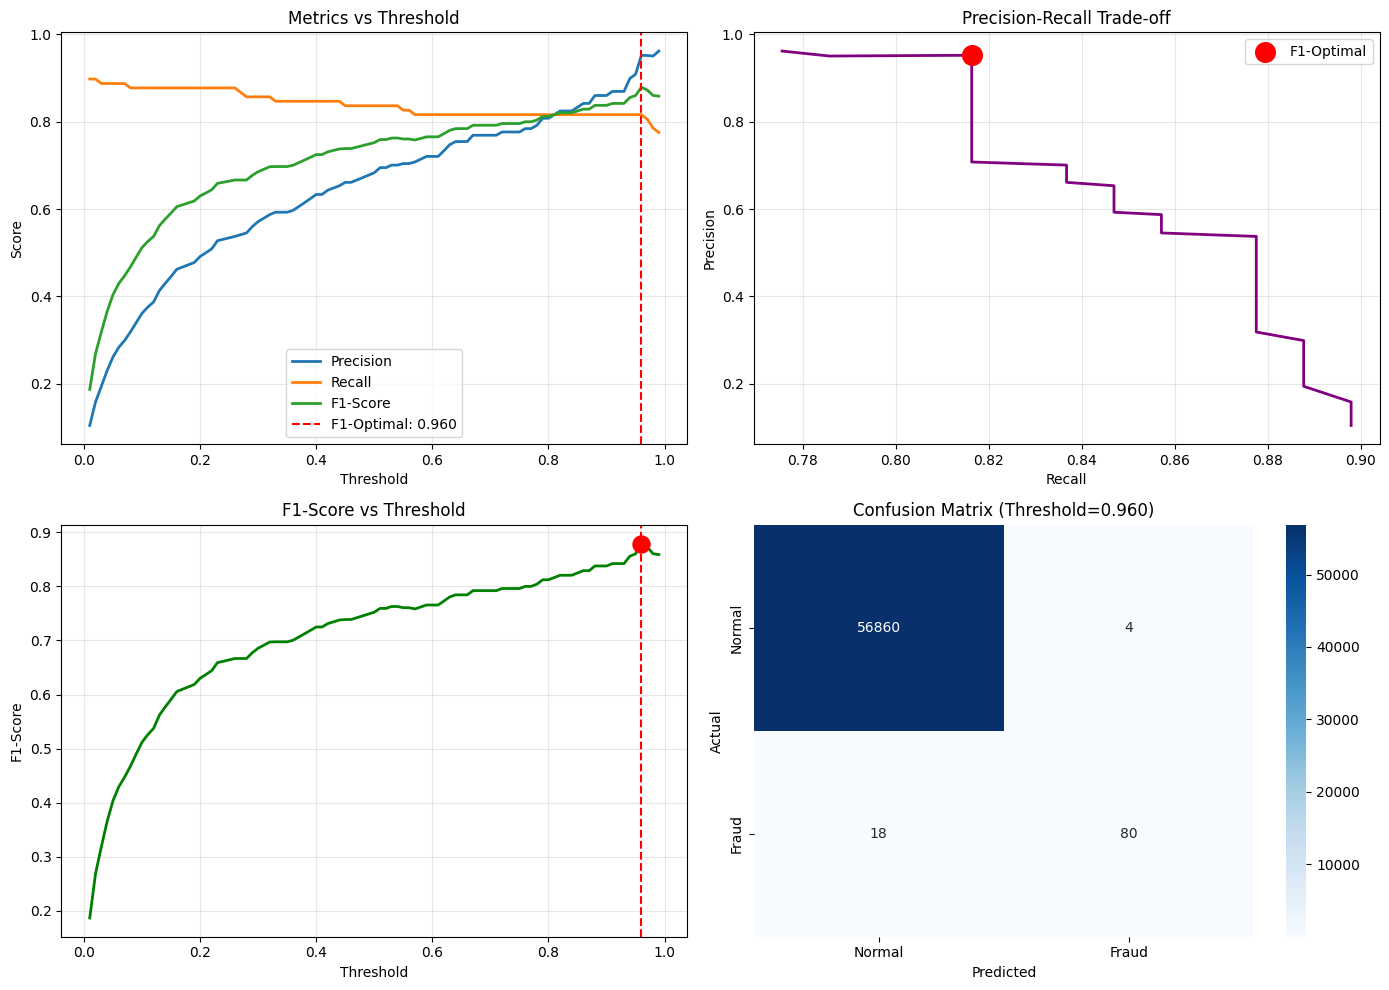

In [6]:
# THRESHOLD OPTIMIZATION

thresholds = np.linspace(0.01, 0.99, 99)
threshold_results = []

for threshold in thresholds:
    y_pred_thresh = (y_proba_test >= threshold).astype(int)
    
    precision = precision_score(y_test, y_pred_thresh, zero_division=0)
    recall = recall_score(y_test, y_pred_thresh, zero_division=0)
    f1 = f1_score(y_test, y_pred_thresh, zero_division=0)
    
    cm_thresh = confusion_matrix(y_test, y_pred_thresh)
    tn_t, fp_t, fn_t, tp_t = cm_thresh.ravel()
    
    threshold_results.append({
        'threshold': threshold,
        'precision': precision,
        'recall': recall,
        'f1': f1,
        'tp': tp_t,
        'fp': fp_t,
        'fn': fn_t,
        'tn': tn_t
    })

results_df = pd.DataFrame(threshold_results)
print(f"Tested {len(thresholds)} thresholds")

# Find F1-optimal threshold
f1_optimal_idx = results_df['f1'].idxmax()
f1_optimal_threshold = results_df.loc[f1_optimal_idx, 'threshold']
f1_optimal_metrics = results_df.loc[f1_optimal_idx]

print(f"\nF1-Optimal Threshold: {f1_optimal_threshold:.3f}")
print(f"  Precision: {f1_optimal_metrics['precision']*100:.2f}%")
print(f"  Recall: {f1_optimal_metrics['recall']*100:.2f}%")
print(f"  F1-Score: {f1_optimal_metrics['f1']*100:.2f}%")
print(f"  Frauds caught: {f1_optimal_metrics['tp']:.0f}/{total_frauds}")

# Find 90%+ recall threshold
recall_90_df = results_df[results_df['recall'] >= 0.90]
if len(recall_90_df) > 0:
    best_90_idx = recall_90_df['precision'].idxmax()
    recall_90_threshold = results_df.loc[best_90_idx, 'threshold']
    recall_90_metrics = results_df.loc[best_90_idx]
    
    print(f"\n90%+ Recall Threshold: {recall_90_threshold:.3f}")
    print(f"  Precision: {recall_90_metrics['precision']*100:.2f}%")
    print(f"  Recall: {recall_90_metrics['recall']*100:.2f}%")
    print(f"  Frauds caught: {recall_90_metrics['tp']:.0f}/{total_frauds}")

# Visualizations
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Metrics vs Threshold
axes[0, 0].plot(results_df['threshold'], results_df['precision'], label='Precision', linewidth=2)
axes[0, 0].plot(results_df['threshold'], results_df['recall'], label='Recall', linewidth=2)
axes[0, 0].plot(results_df['threshold'], results_df['f1'], label='F1-Score', linewidth=2)
axes[0, 0].axvline(f1_optimal_threshold, color='red', linestyle='--', label=f'F1-Optimal: {f1_optimal_threshold:.3f}')
axes[0, 0].set_xlabel('Threshold')
axes[0, 0].set_ylabel('Score')
axes[0, 0].set_title('Metrics vs Threshold')
axes[0, 0].legend()
axes[0, 0].grid(alpha=0.3)

# Precision-Recall Curve
axes[0, 1].plot(results_df['recall'], results_df['precision'], linewidth=2, color='purple')
axes[0, 1].scatter([f1_optimal_metrics['recall']], [f1_optimal_metrics['precision']], 
                   s=200, color='red', zorder=5, label='F1-Optimal')
axes[0, 1].set_xlabel('Recall')
axes[0, 1].set_ylabel('Precision')
axes[0, 1].set_title('Precision-Recall Trade-off')
axes[0, 1].legend()
axes[0, 1].grid(alpha=0.3)

# F1-Score vs Threshold
axes[1, 0].plot(results_df['threshold'], results_df['f1'], linewidth=2, color='green')
axes[1, 0].axvline(f1_optimal_threshold, color='red', linestyle='--')
axes[1, 0].scatter([f1_optimal_threshold], [f1_optimal_metrics['f1']], s=150, color='red', zorder=5)
axes[1, 0].set_xlabel('Threshold')
axes[1, 0].set_ylabel('F1-Score')
axes[1, 0].set_title('F1-Score vs Threshold')
axes[1, 0].grid(alpha=0.3)

# Confusion Matrix at F1-Optimal
cm_f1 = confusion_matrix(y_test, (y_proba_test >= f1_optimal_threshold).astype(int))
sns.heatmap(cm_f1, annot=True, fmt='d', cmap='Blues', ax=axes[1, 1],
            xticklabels=['Normal', 'Fraud'], yticklabels=['Normal', 'Fraud'])
axes[1, 1].set_title(f'Confusion Matrix (Threshold={f1_optimal_threshold:.3f})')
axes[1, 1].set_ylabel('Actual')
axes[1, 1].set_xlabel('Predicted')

plt.tight_layout()
plt.show()
plt.close()

## Cost-Sensitive Evaluation

We will now determine what is the cost-optimal threshold, evaluate business impact, and list our final recommendation


Cost Matrix:
  False Negative: $100 (missed fraud)
  False Positive: $10 (manual review)
  True Positive: $-1 (reward)
  True Negative: $0
  Ratio: 10.0:1

Cost-Optimal Threshold: 0.960
  Recall: 81.63%
  Precision: 95.24%
  Total Cost: $1760
  FN: 18, FP: 4

Comparison:
  F1-Optimal (0.960): $1760
  Cost-Optimal (0.960): $1760
  Difference: $0
  F1-optimal and cost-optimal are nearly identical


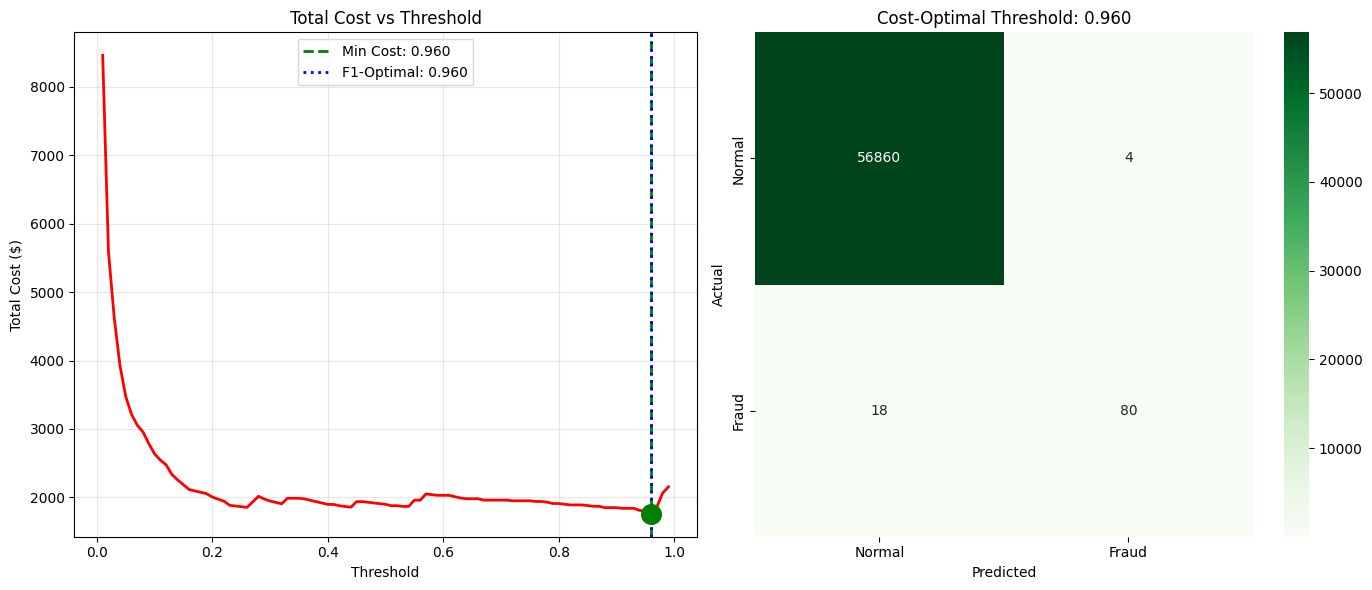


Business Impact:
  Default threshold cost: $2062
  Optimized threshold cost: $1760
  Savings: $302 per 56,962 transactions
  Annual savings per 1M: $5,301.78

Recommended threshold: 0.960 (F1-optimal)

Final Performance:
  Recall: 81.63%
  Precision: 95.24%
  F1-Score: 87.91%
  Frauds caught: 80/98
  False alarms: 4
  Cost: $1760


In [8]:
# Define cost matrix
COST_FN = 100
COST_FP = 10
COST_TP = -1
COST_TN = 0

print(f"\nCost Matrix:")
print(f"  False Negative: ${COST_FN} (missed fraud)")
print(f"  False Positive: ${COST_FP} (manual review)")
print(f"  True Positive: ${COST_TP} (reward)")
print(f"  True Negative: ${COST_TN}")
print(f"  Ratio: {COST_FN/COST_FP}:1")

# Calculate cost for each threshold
results_df['total_cost'] = (
    (results_df['fn'] * COST_FN) + 
    (results_df['fp'] * COST_FP) + 
    (results_df['tp'] * COST_TP)
)

# Find cost-optimal threshold
cost_optimal_idx = results_df['total_cost'].idxmin()
cost_optimal_threshold = results_df.loc[cost_optimal_idx, 'threshold']
cost_optimal_cost = results_df.loc[cost_optimal_idx, 'total_cost']
cost_optimal_metrics = results_df.loc[cost_optimal_idx]

print(f"\nCost-Optimal Threshold: {cost_optimal_threshold:.3f}")
print(f"  Recall: {cost_optimal_metrics['recall']*100:.2f}%")
print(f"  Precision: {cost_optimal_metrics['precision']*100:.2f}%")
print(f"  Total Cost: ${cost_optimal_cost:.0f}")
print(f"  FN: {cost_optimal_metrics['fn']:.0f}, FP: {cost_optimal_metrics['fp']:.0f}")

# Compare F1-optimal vs Cost-optimal
f1_cost = results_df.loc[f1_optimal_idx, 'total_cost']
cost_difference = f1_cost - cost_optimal_cost

print(f"\nComparison:")
print(f"  F1-Optimal ({f1_optimal_threshold:.3f}): ${f1_cost:.0f}")
print(f"  Cost-Optimal ({cost_optimal_threshold:.3f}): ${cost_optimal_cost:.0f}")
print(f"  Difference: ${cost_difference:.0f}")

if abs(cost_difference) < 50:
    print(f"  F1-optimal and cost-optimal are nearly identical")
elif cost_optimal_cost < f1_cost:
    print(f"  Cost-optimal saves ${cost_difference:.0f}")

# Visualizations
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Cost vs Threshold
axes[0].plot(results_df['threshold'], results_df['total_cost'], linewidth=2, color='red')
axes[0].axvline(cost_optimal_threshold, color='green', linestyle='--', linewidth=2, 
                label=f'Min Cost: {cost_optimal_threshold:.3f}')
axes[0].axvline(f1_optimal_threshold, color='blue', linestyle=':', linewidth=2,
                label=f'F1-Optimal: {f1_optimal_threshold:.3f}')
axes[0].scatter([cost_optimal_threshold], [cost_optimal_cost], s=200, color='green', zorder=5)
axes[0].set_xlabel('Threshold')
axes[0].set_ylabel('Total Cost ($)')
axes[0].set_title('Total Cost vs Threshold')
axes[0].legend()
axes[0].grid(alpha=0.3)

# Confusion Matrix at Cost-Optimal
cm_cost = confusion_matrix(y_test, (y_proba_test >= cost_optimal_threshold).astype(int))
sns.heatmap(cm_cost, annot=True, fmt='d', cmap='Greens', ax=axes[1],
            xticklabels=['Normal', 'Fraud'], yticklabels=['Normal', 'Fraud'])
axes[1].set_title(f'Cost-Optimal Threshold: {cost_optimal_threshold:.3f}')
axes[1].set_ylabel('Actual')
axes[1].set_xlabel('Predicted')

plt.tight_layout()
plt.show()
plt.close()

# Calculate business impact
baseline_cost = (fn * COST_FN) + (fp * COST_FP) - (tp * COST_TP)
optimized_cost = cost_optimal_cost
savings = baseline_cost - optimized_cost
savings_per_million = savings * (1_000_000 / len(y_test))

print(f"\nBusiness Impact:")
print(f"  Default threshold cost: ${baseline_cost:.0f}")
print(f"  Optimized threshold cost: ${optimized_cost:.0f}")
print(f"  Savings: ${savings:.0f} per {len(y_test):,} transactions")
print(f"  Annual savings per 1M: ${savings_per_million:,.2f}")

# Final recommendation
if abs(cost_optimal_threshold - f1_optimal_threshold) < 0.05:
    recommended_threshold = f1_optimal_threshold
    print(f"\nRecommended threshold: {recommended_threshold:.3f} (F1-optimal)")
else:
    recommended_threshold = cost_optimal_threshold
    print(f"\nRecommended threshold: {recommended_threshold:.3f} (Cost-optimal)")
    print(f"Saves ${cost_difference:.0f} vs F1-optimal")

recommended_metrics = results_df.loc[results_df['threshold'] == recommended_threshold].iloc[0]

print(f"\nFinal Performance:")
print(f"  Recall: {recommended_metrics['recall']*100:.2f}%")
print(f"  Precision: {recommended_metrics['precision']*100:.2f}%")
print(f"  F1-Score: {recommended_metrics['f1']*100:.2f}%")
print(f"  Frauds caught: {recommended_metrics['tp']:.0f}/{total_frauds}")
print(f"  False alarms: {recommended_metrics['fp']:.0f}")
print(f"  Cost: ${recommended_metrics['total_cost']:.0f}")